In [43]:
print("ML start 🚀")

ML start 🚀


In [44]:
import pandas as pd

ratings = pd.read_csv("data/raw/ratings.csv")
movies = pd.read_csv("data/raw/movies.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


In [45]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 610.4 MB


In [46]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB


In [47]:
ratings.describe()

,userId,movieId,rating,timestamp
count,2.000026e+07,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00,1.100918e+09
std,4.003863e+04,1.978948e+04,1.051989e+00,1.621694e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,3.439500e+04,9.020000e+02,3.000000e+00,9.667977e+08
50%,6.914100e+04,2.167000e+03,3.500000e+00,1.103556e+09
75%,1.036370e+05,4.770000e+03,4.000000e+00,1.225642e+09
max,1.384930e+05,1.312620e+05,5.000000e+00,1.427784e+09


In [48]:
print("Users:", ratings['userId'].nunique())
print("Movies:", ratings['movieId'].nunique())

Users: 138493
Movies: 26744


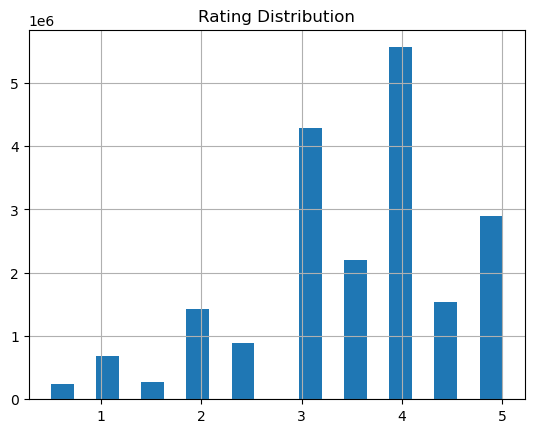

In [49]:
import matplotlib.pyplot as plt

ratings['rating'].hist(bins=20)
plt.title("Rating Distribution")
plt.show()

In [50]:
data = pd.merge(ratings, movies, on='movieId')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,2,3.5,1112486027,Jumanji (1995),Adventure|Children|Fantasy
1,1,29,3.5,1112484676,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
2,1,32,3.5,1112484819,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,3.5,1112484727,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,3.5,1112484580,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [51]:
movie_stats = data.groupby('title').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = ['avg_rating', 'rating_count']
movie_stats.head()

,avg_rating,rating_count
title,,
"""Great Performances"" Cats (1998)",2.748387,155
#chicagoGirl: The Social Network Takes on a Dictator (2013),3.666667,3
$ (Dollars) (1971),2.833333,24
$5 a Day (2008),2.871795,39
$9.99 (2008),3.009091,55


In [52]:
popular_movies = movie_stats.sort_values(by='rating_count', ascending=False)

popular_movies.head(10)

,avg_rating,rating_count
title,,
Pulp Fiction (1994),4.174231,67310
Forrest Gump (1994),4.029000,66172
"Shawshank Redemption, The (1994)",4.446990,63366
"Silence of the Lambs, The (1991)",4.177057,63299
Jurassic Park (1993),3.664741,59715
Star Wars: Episode IV - A New Hope (1977),4.190672,54502
Braveheart (1995),4.042534,53769
Terminator 2: Judgment Day (1991),3.931954,52244
"Matrix, The (1999)",4.187186,51334


In [53]:
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings shape: (20000263, 4)
Movies shape: (27278, 3)


In [54]:
print(ratings.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index(['movieId', 'title', 'genres'], dtype='object')


In [55]:
print("Total ratings:", len(ratings))
print("Total movies:", len(movies))

Total ratings: 20000263
Total movies: 27278


In [56]:
import pandas as pd

ratings = pd.read_csv("data/raw/ratings.csv")
movies = pd.read_csv("data/raw/movies.csv")

In [57]:
data = pd.merge(ratings, movies, on='movieId')

In [58]:
sample_data = data.sample(50000)

In [59]:
user_movie_matrix = sample_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

In [60]:
user_movie_matrix_filled = user_movie_matrix.fillna(0)

In [61]:
data

,userId,movieId,rating,timestamp,title,genres
0,1,2,3.5,1112486027,Jumanji (1995),Adventure|Children|Fantasy
1,1,29,3.5,1112484676,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
2,1,32,3.5,1112484819,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,3.5,1112484727,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,3.5,1112484580,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...
20000258,138493,68954,4.5,1258126920,Up (2009),Adventure|Animation|Children|Drama
20000259,138493,69526,4.5,1259865108,Transformers: Revenge of the Fallen (2009),Action|Adventure|Sci-Fi|IMAX
20000260,138493,69644,3.0,1260209457,Ice Age: Dawn of the Dinosaurs (2009),Action|Adventure|Animation|Children|Comedy|Rom...
20000261,138493,70286,5.0,1258126944,District 9 (2009),Mystery|Sci-Fi|Thriller


In [62]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_movie_matrix_filled)

In [63]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

In [64]:
user_similarity_df.head()

userId,3,7,11,23,24,26,29,31,43,48,...,138467,138472,138474,138475,138476,138477,138483,138484,138490,138493
userId,,,,,,,,,,,,,,,,,,,,,
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
11,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
user_movie_matrix.index[:10]

Index([3, 7, 11, 23, 24, 26, 29, 31, 43, 48], dtype='int64', name='userId')

In [66]:
user_similarity_df[3].sort_values(ascending=False).head(10)

userId
3         1.0
77198     1.0
40042     1.0
57453     1.0
6108      1.0
38020     1.0
110194    1.0
105757    1.0
70340     1.0
23937     1.0
Name: 3, dtype: float64

In [67]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def get_similar_users(user_id, top_n=10):

    user_vector = user_movie_matrix_filled.loc[user_id].values.reshape(1, -1)

    similarity = cosine_similarity(user_vector, user_movie_matrix_filled)[0]

    similarity_series = pd.Series(similarity, index=user_movie_matrix.index)

    similar_users = similarity_series.sort_values(ascending=False)[1:top_n+1]

    return similar_users

In [68]:
user_id = 3  # ya koi valid user

similar_users = get_similar_users(user_id, top_n=56)

similar_users_ids = similar_users.index

In [69]:
similar_users_data = sample_data[
    sample_data['userId'].isin(similar_users_ids)
]

In [70]:
user_seen_movies = sample_data[
    sample_data['userId'] == user_id
]['title'].tolist()

In [71]:
recommendations = similar_users_data[
    ~similar_users_data['title'].isin(user_seen_movies)
]

In [72]:
recommended_movies = (
    recommendations
    .groupby('title')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

recommended_movies

title
Fargo (1996)                                 5.0
Mo' Better Blues (1990)                      5.0
Thin Red Line, The (1998)                    5.0
Being John Malkovich (1999)                  5.0
Logan's Run (1976)                           5.0
Chinatown (1974)                             5.0
Sound of Music, The (1965)                   5.0
Indiana Jones and the Last Crusade (1989)    4.5
Traffic (2000)                               4.5
Princess Bride, The (1987)                   4.5
Name: rating, dtype: float64

In [73]:
recommended_movies = (
    similar_users_data
    .groupby('title')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

recommended_movies

title
Logan's Run (1976)                   5.0
Sound of Music, The (1965)           5.0
Fargo (1996)                         5.0
Mo' Better Blues (1990)              5.0
Being John Malkovich (1999)          5.0
Chinatown (1974)                     5.0
Thin Red Line, The (1998)            5.0
Sucker Punch (2011)                  4.5
Princess Bride, The (1987)           4.5
Chronicles of Riddick, The (2004)    4.5
Name: rating, dtype: float64

In [74]:
def recommend_movies(user_id, n_recommendations=10):

    # Step 1: Similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]
    similar_users_ids = similar_users.index

    # Step 2: Similar users ka data
    similar_users_data = sample_data[
        sample_data['userId'].isin(similar_users_ids)
    ]

    # Step 3: Movies jo user ne already dekhi hain
    user_seen_movies = sample_data[
        sample_data['userId'] == user_id
    ]['title'].tolist()

    # Step 4: Unseen movies filter karo
    recommendations = similar_users_data[
        ~similar_users_data['title'].isin(user_seen_movies)
    ]

    # Step 5: Top rated movies
    recommended_movies = (
        recommendations
        .groupby('title')['rating']
        .mean()
        .sort_values(ascending=False)
        .head(n_recommendations)
    )

    return recommended_movies

In [75]:
movie_counts = sample_data['title'].value_counts()

popular_movies = movie_counts[movie_counts > 50].index

sample_data = sample_data[sample_data['title'].isin(popular_movies)]


In [76]:
user_movie_matrix = sample_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

In [77]:
user_movie_matrix_filled = user_movie_matrix.fillna(0)

In [78]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_users(user_id, top_n=10):

    user_vector = user_movie_matrix_filled.loc[user_id].values.reshape(1, -1)

    similarity = cosine_similarity(user_vector, user_movie_matrix_filled)[0]

    similarity_series = pd.Series(similarity, index=user_movie_matrix.index)

    similar_users = similarity_series.sort_values(ascending=False)[1:top_n+1]

    return similar_users

In [79]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [80]:
touch app.py

SyntaxError: invalid syntax (4097220051.py, line 1)